In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
mental_health = pd.read_csv("../Teen_Mental_Health_Dataset.csv")
mental_health.head(5)

mental_health.info()
# ? No nulls in the base
mental_health.describe()
# ? General view of the base
mental_health.shape
# ? 1200 x 13
mental_health.dtypes
# ? Everything with the data types = OK

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [ ]:
# Creating auxilary columns
mental_health["usage_group"] = pd.cut(
    mental_health["daily_social_media_hours"],
    bins=[0, 2, 4, 6, 24],
    labels=["low", "moderate", "high", "very_high"]
)
mental_health["usage_group"].value_counts()

print(mental_health.groupby("usage_group", observed=True)["anxiety_level"].mean())


mental_health["sleep_group"] = pd.cut(
    mental_health["sleep_hours"],
    bins=[0, 4, 6, 10],
    labels=["very low", "low", "normal"]
)

print(mental_health.groupby("sleep_group", observed=True)["anxiety_level"].mean())


mental_health["screen_time_before_sleep_group"] = pd.cut(
    mental_health["screen_time_before_sleep"],
    bins=[0, 1, 4],
    labels=["low", "high"],
    include_lowest=True
)

print(mental_health.groupby("screen_time_before_sleep_group", observed=True)["anxiety_level"].mean())




usage_group
low          5.284884
moderate     5.735955
high         5.770833
very_high    5.577381
Name: anxiety_level, dtype: float64
sleep_group
very low    5.400000
low         5.710794
normal      5.587983
Name: anxiety_level, dtype: float64
screen_time_before_sleep_group
low     5.688462
high    5.622340
Name: anxiety_level, dtype: float64


In [25]:
numeric_cols = [
    "daily_social_media_hours",
    "screen_time_before_sleep",
    "sleep_hours",
    "stress_level",
    "anxiety_level",
    "academic_performance",
    "physical_activity",
]

mental_health[numeric_cols].describe()

,daily_social_media_hours,screen_time_before_sleep,sleep_hours,stress_level,anxiety_level,academic_performance,physical_activity
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,4.536667,1.740333,6.449417,5.445833,5.636667,2.990383,1.014500
std,2.029599,0.716660,1.442677,2.903290,2.859453,0.576758,0.582185
min,1.000000,0.500000,4.000000,1.000000,1.000000,2.000000,0.000000
25%,2.800000,1.100000,5.200000,3.000000,3.000000,2.500000,0.500000
50%,4.500000,1.800000,6.500000,5.000000,6.000000,2.990000,1.000000
75%,6.300000,2.400000,7.600000,8.000000,8.000000,3.480000,1.500000
max,8.000000,3.000000,9.000000,10.000000,10.000000,4.000000,2.000000


## Analysis of discret and continuos numbers on the data frame
##### Comparating different types of variables from the df with visualization from matplotlib

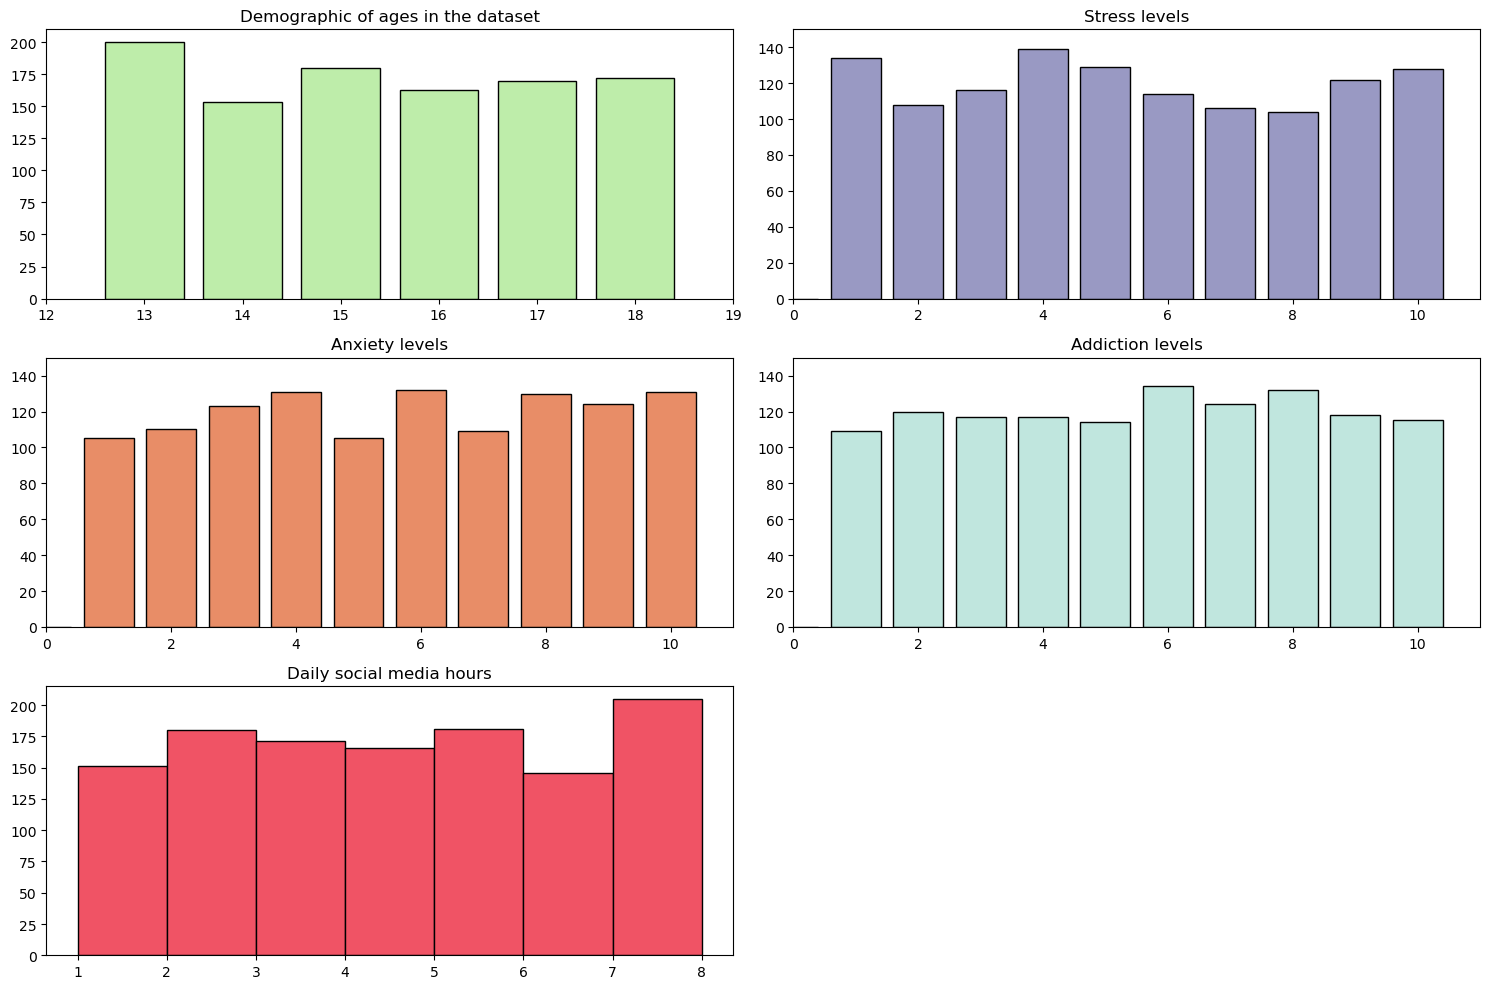

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

# Demographic of ages of the users in the data base
age_counter = Counter(mental_health["age"])
xs = range(13, 19)
ys = [age_counter[x] for x in xs]
color = "#BEEDAA"

axes[0, 0].bar(xs, ys, color=color, edgecolor="black")
axes[0, 0].axis([12, 19, 0, 210])
axes[0, 0].set_title("Demographic of ages in the dataset")

# Stress levels
stress_level_counter = Counter(mental_health["stress_level"])
xs = range(0, 11)
ys = [stress_level_counter[x] for x in xs]

axes[0, 1].bar(xs, ys, color="#9999C3", edgecolor="black")
axes[0, 1].axis([0, 11, 0, 150])
axes[0, 1].set_title("Stress levels")

# Anxiety levels
anxiety_level_counter = Counter(mental_health["anxiety_level"])
xs = range(0, 11)
ys = [anxiety_level_counter[x] for x in xs]

axes[1, 0].bar(xs, ys, color="#E88D67", edgecolor="black")
axes[1, 0].axis([0, 11, 0, 150])
axes[1, 0].set_title("Anxiety levels")

# Addiction levels
addiction_level_counter = Counter(mental_health["addiction_level"])
xs = range(0, 11)
ys = [addiction_level_counter[x] for x in xs]

axes[1, 1].bar(xs, ys, color="#C0E6DE", edgecolor="black")
axes[1, 1].axis([0, 11, 0, 150])
axes[1, 1].set_title("Addiction levels")

# Daily social media hours
axes[2, 0].hist(
    mental_health["daily_social_media_hours"],
    color="#F05365",
    edgecolor="black",
    bins=7
)
axes[2, 0].set_title("Daily social media hours")

# Hide the empty subplot
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()


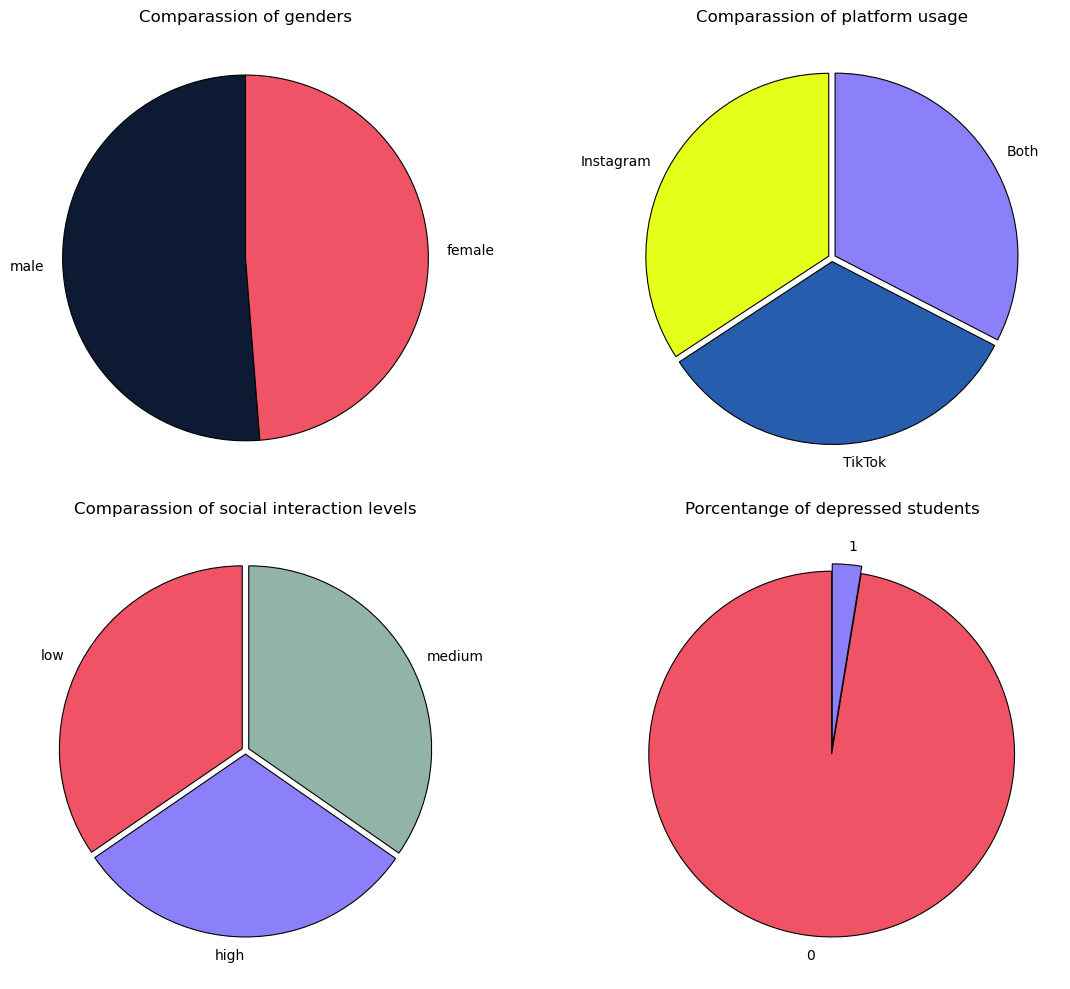

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Comparing genders
gender_count = Counter(mental_health["gender"])
labels = list(gender_count.keys())
values = list(gender_count.values())
colors = ["#0C1B33", "#F05365"]

axes[0, 0].set_title("Comparassion of genders")
axes[0, 0].pie(
    values,
    labels=labels,
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

# Comparing platform usage
platform_usage_count = Counter(mental_health["platform_usage"])
labels = list(platform_usage_count.keys())
values = list(platform_usage_count.values())
colors = ["#E4FF1A", "#275DAD", "#8B80F9"]
explode = [0.02, 0.02, 0.02]

axes[0, 1].set_title("Comparassion of platform usage")
axes[0, 1].pie(
    values,
    labels=labels,
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

# Social interaction level
social_interaction_level_counter = Counter(mental_health["social_interaction_level"])
labels = list(social_interaction_level_counter.keys())
values = list(social_interaction_level_counter.values())
colors = ["#F05365", "#8B80F9", "#92B4A7"]
explode = [0.02, 0.02, 0.02]

axes[1, 0].set_title("Comparassion of social interaction levels")
axes[1, 0].pie(
    values,
    labels=labels,
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

# Depression label
depression_label_counter = Counter(mental_health["depression_label"])
labels = list(depression_label_counter.keys())
values = list(depression_label_counter.values())
colors = ["#F05365", "#8B80F9"]
explode = [0.02, 0.02]

axes[1, 1].set_title("Porcentange of depressed students")
axes[1, 1].pie(
    values,
    labels=labels,
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

plt.tight_layout()
plt.show()


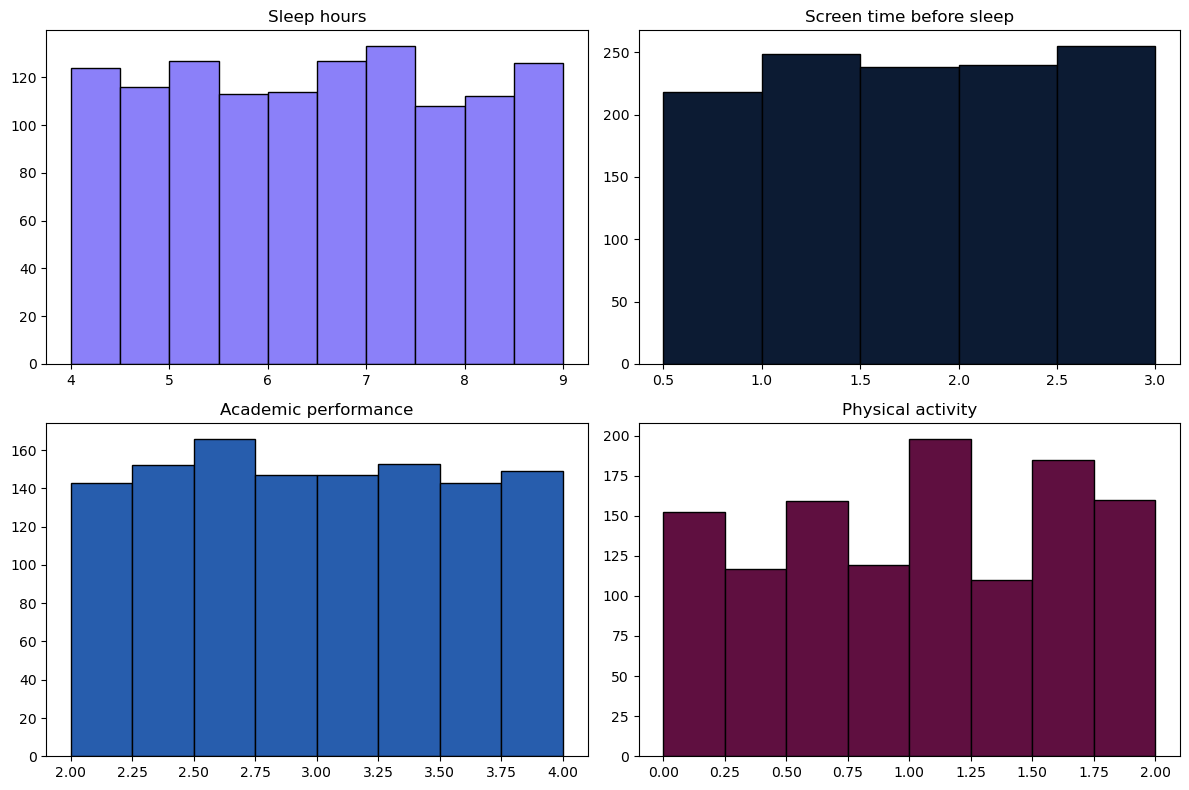

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Sleep hours
axes[0, 0].hist(
    mental_health["sleep_hours"],
    color="#8B80F9",
    edgecolor="black",
    bins=10
)
axes[0, 0].set_title("Sleep hours")

# Screen time before sleep
axes[0, 1].hist(
    mental_health["screen_time_before_sleep"],
    color="#0C1B33",
    edgecolor="black",
    bins=5
)
axes[0, 1].set_title("Screen time before sleep")

# Academic performance
axes[1, 0].hist(
    mental_health["academic_performance"],
    color="#275DAD",
    edgecolor="black",
    bins=8
)
axes[1, 0].set_title("Academic performance")

# Physical activity
axes[1, 1].hist(
    mental_health["physical_activity"],
    color="#5F0F40",
    edgecolor="black",
    bins=8
)
axes[1, 1].set_title("Physical activity")

plt.tight_layout()
plt.show()


# Checking correlation between variables

In [13]:
corr_columns = [
        "daily_social_media_hours",
        "screen_time_before_sleep",
        "sleep_hours",
        "stress_level",
        "depression_label",
        "anxiety_level",
        "academic_performance",
        "physical_activity",
]


mental_health[corr_columns].corr()

,daily_social_media_hours,screen_time_before_sleep,sleep_hours,stress_level,depression_label,anxiety_level,academic_performance,physical_activity
daily_social_media_hours,1.000000,0.035777,-0.009472,0.030698,0.175201,0.027835,0.013179,0.025546
screen_time_before_sleep,0.035777,1.000000,0.010235,-0.008650,-0.016502,-0.010344,-0.034715,-0.026450
sleep_hours,-0.009472,0.010235,1.000000,-0.010979,-0.190630,-0.011879,0.021866,0.012701
stress_level,0.030698,-0.008650,-0.010979,1.000000,0.170474,0.015811,-0.000600,0.012159
depression_label,0.175201,-0.016502,-0.190630,0.170474,1.000000,0.169566,0.001441,-0.017598
anxiety_level,0.027835,-0.010344,-0.011879,0.015811,0.169566,1.000000,-0.064379,-0.022233
academic_performance,0.013179,-0.034715,0.021866,-0.000600,0.001441,-0.064379,1.000000,0.023312
physical_activity,0.025546,-0.026450,0.012701,0.012159,-0.017598,-0.022233,0.023312,1.000000


# Checking the correlations by different types of groups
##### (age_group, adictiviness_group and others). 

In [ ]:


mental_health["age_group"] =pd.cut(
    mental_health["age"],
    bins=[12, 15, 18], # Starts with 13 and ends with 18
    labels=["13-15","16-18"]
)

for age_group, group_df in mental_health.groupby("age_group"):
    print(f"\nAge group: {age_group}")
    print(group_df[corr_columns].corr())


Age group: 13-15
                          daily_social_media_hours  screen_time_before_sleep  \
daily_social_media_hours                  1.000000                  0.055517   
screen_time_before_sleep                  0.055517                  1.000000   
sleep_hours                              -0.059811                 -0.006175   
stress_level                              0.049313                  0.008496   
depression_label                          0.189863                 -0.006168   
anxiety_level                            -0.018251                  0.002871   
academic_performance                     -0.007781                 -0.056528   
physical_activity                        -0.008732                  0.054356   

                          sleep_hours  stress_level  depression_label  \
daily_social_media_hours    -0.059811      0.049313          0.189863   
screen_time_before_sleep    -0.006175      0.008496         -0.006168   
sleep_hours                  1.000000     

C:\Users\leona\AppData\Local\Temp\ipykernel_3660\2536365380.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for age_group, group_df in mental_health.groupby("age_group"):


In [17]:
mental_health.groupby("usage_group")[
    ["anxiety_level", "stress_level", "depression_label"]
].mean()

C:\Users\leona\AppData\Local\Temp\ipykernel_3660\578364907.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mental_health.groupby("usage_group")[


,anxiety_level,stress_level,depression_label
usage_group,,,
low,5.284884,5.610465,0.000000
moderate,5.735955,5.264045,0.000000
high,5.770833,5.235119,0.026786
very_high,5.577381,5.764881,0.065476


In [21]:
print(mental_health.groupby("usage_group", observed=False)["depression_label"].agg(["count", "sum", "mean"]))
print(mental_health.groupby("usage_group", observed=False)[["anxiety_level", "stress_level"]].mean())
print(mental_health.groupby("usage_group", observed=False)[["anxiety_level", "stress_level"]].median())


             count  sum      mean
usage_group                      
low            172    0  0.000000
moderate       356    0  0.000000
high           336    9  0.026786
very_high      336   22  0.065476
             anxiety_level  stress_level
usage_group                             
low               5.284884      5.610465
moderate          5.735955      5.264045
high              5.770833      5.235119
very_high         5.577381      5.764881
             anxiety_level  stress_level
usage_group                             
low                    5.0           5.0
moderate               6.0           5.0
high                   6.0           5.0
very_high              5.0           6.0


In [23]:
pd.crosstab(mental_health["usage_group"], mental_health["depression_label"])

depression_label,0,1
usage_group,,
low,172,0
moderate,356,0
high,327,9
very_high,314,22


# Searching for outliers

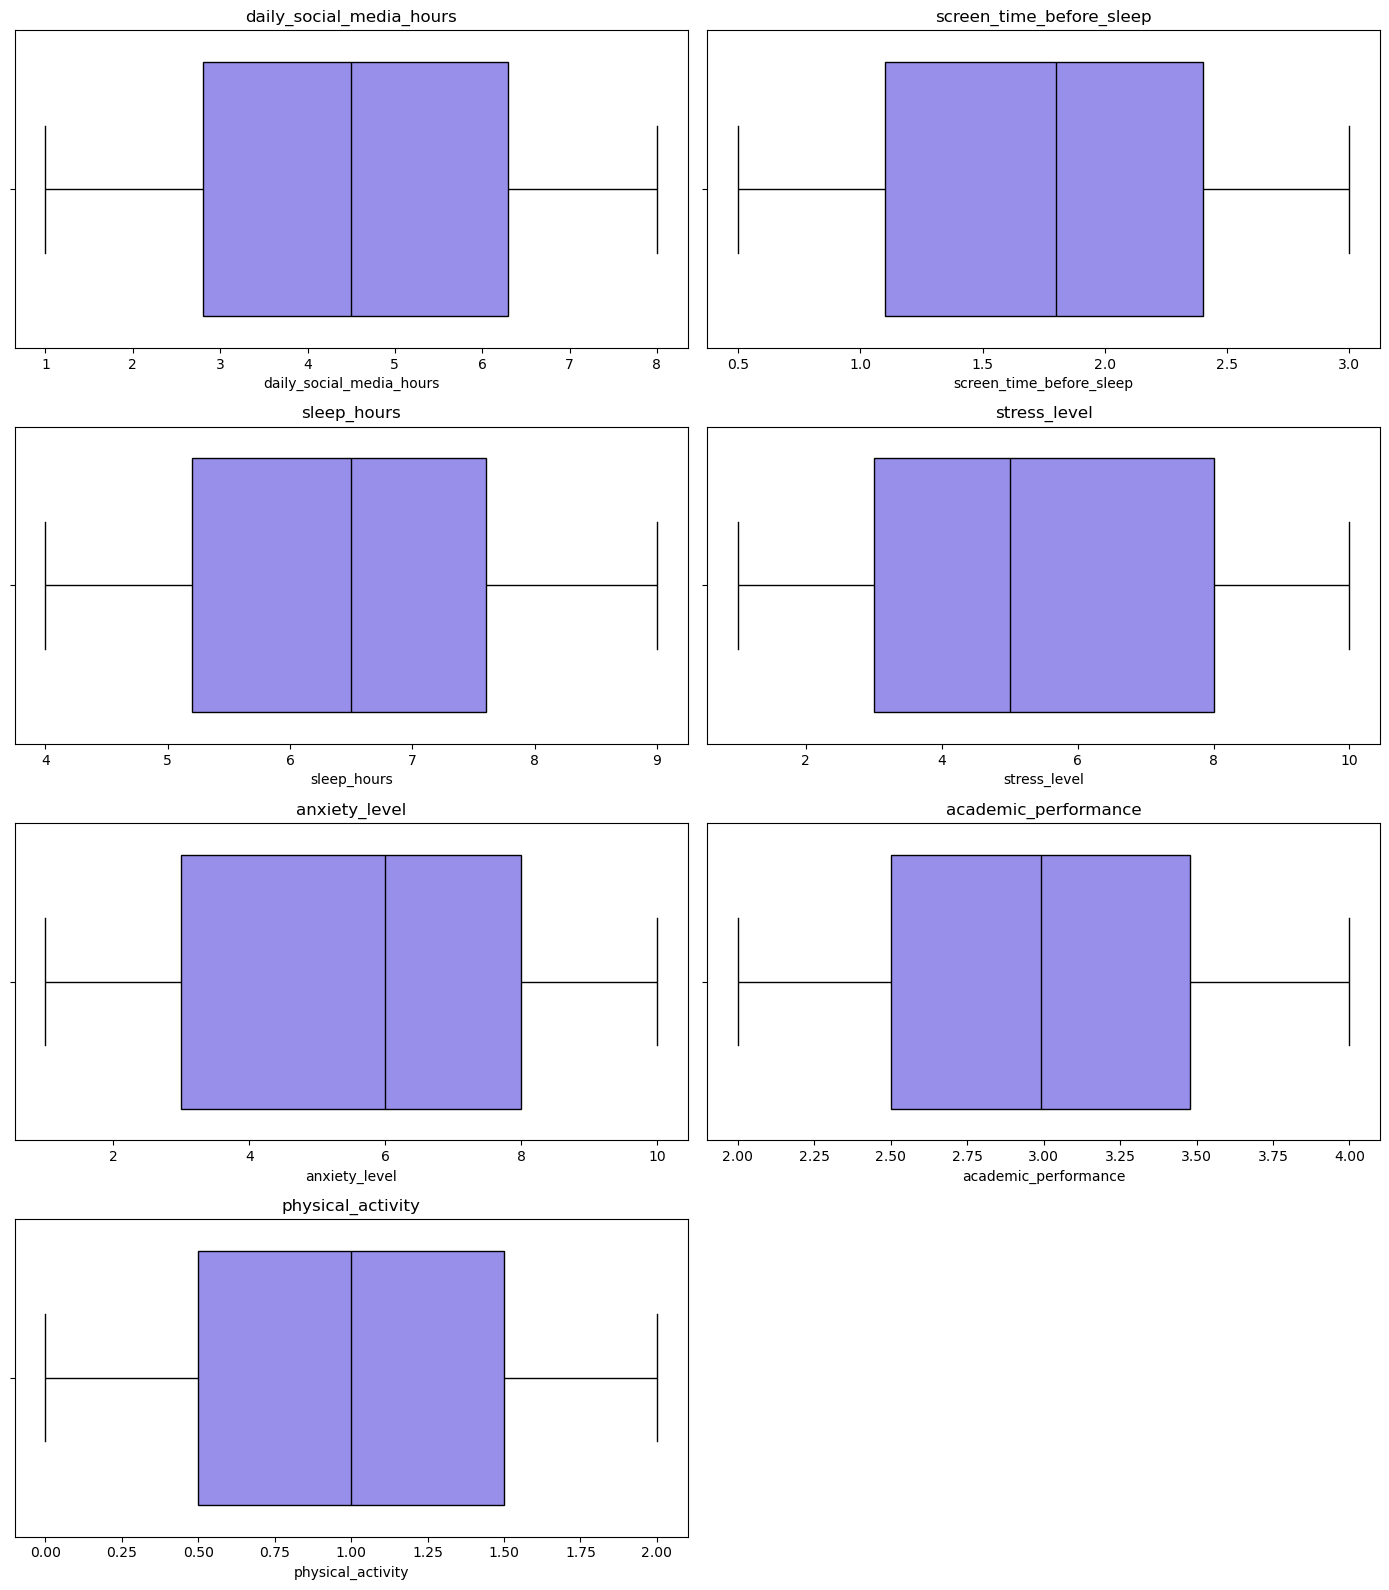

In [30]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=mental_health[col], ax=axes[i], color="#8B80F9", linecolor="#000000")
    axes[i].set_title(col)

# Hide any extra empty subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


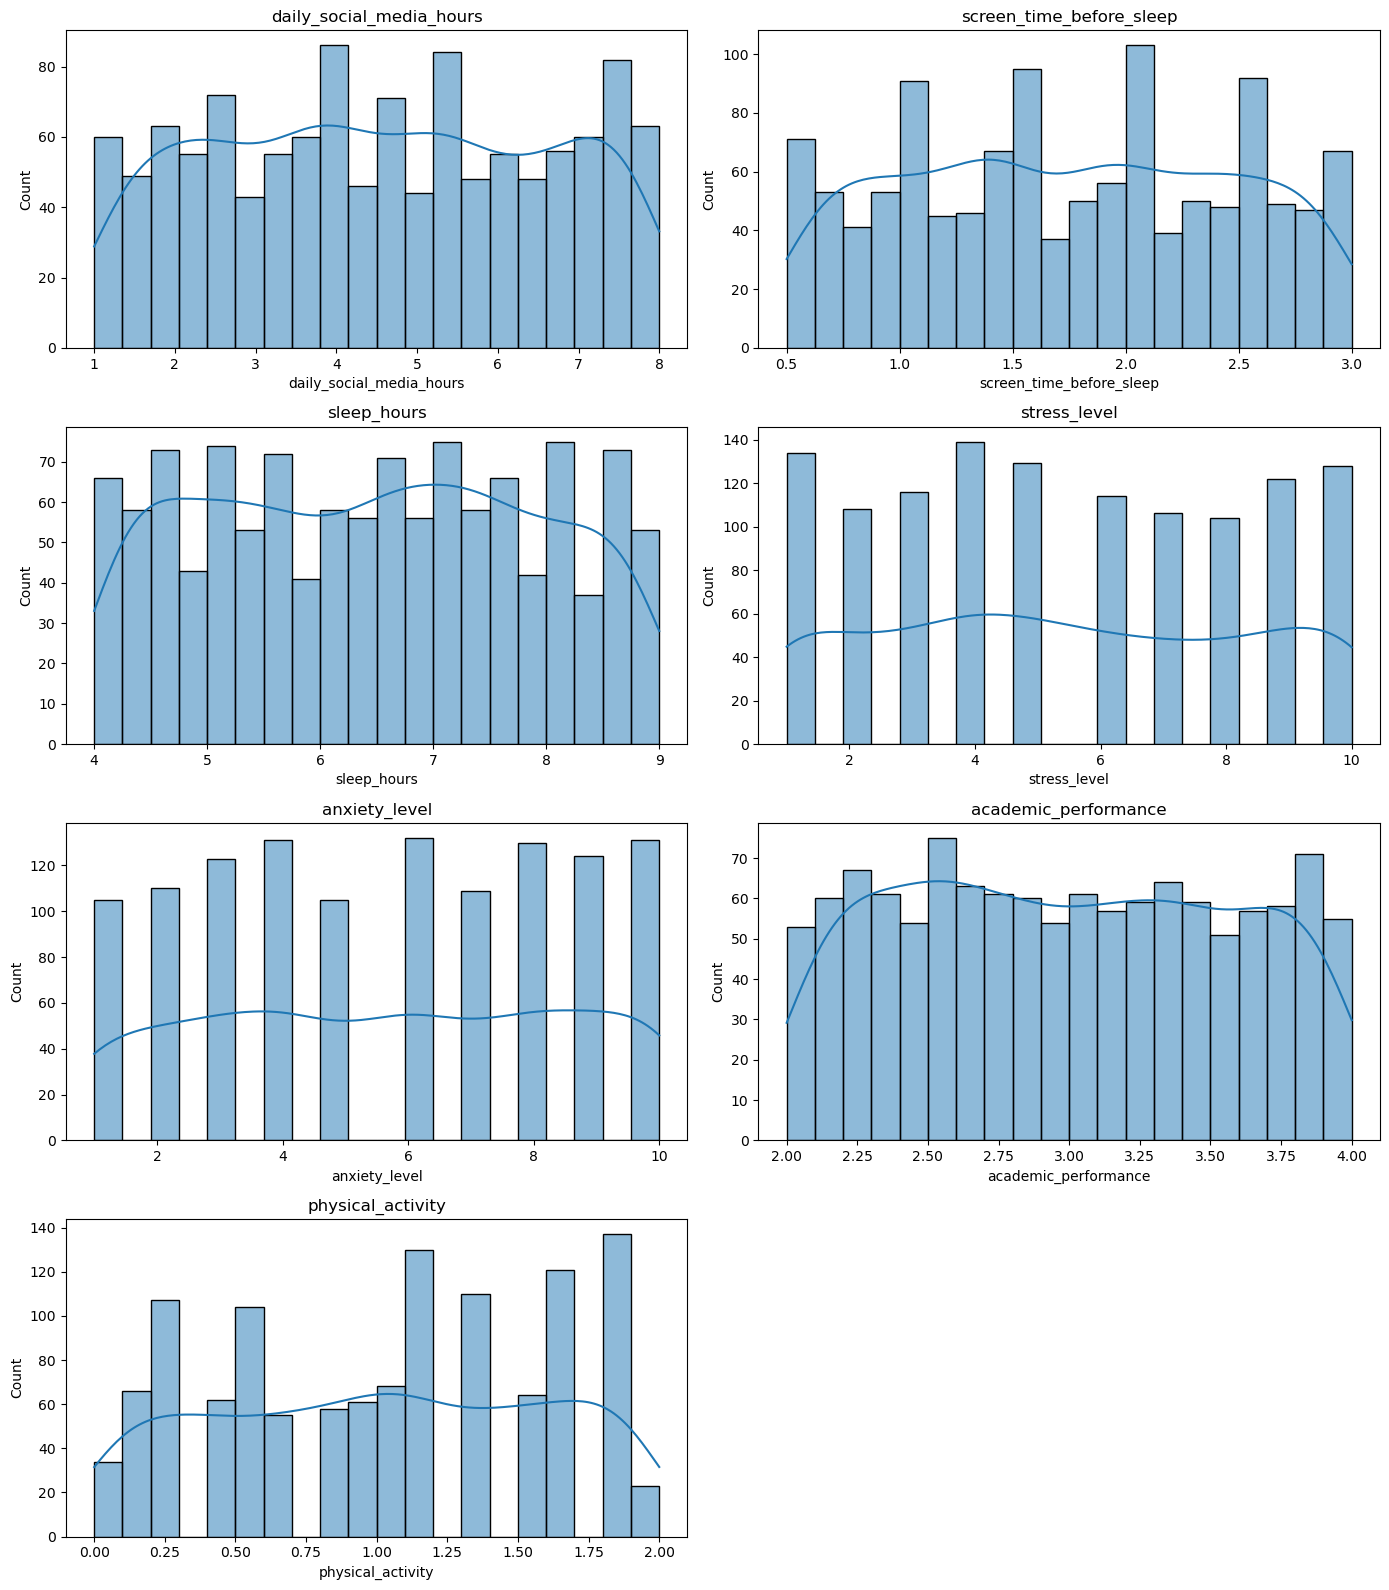

In [32]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        mental_health[col],
        bins=20,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


# Comparing if the social media addicteds have a healthy lifestyle.

In [33]:
# Seeing if the social media addicted do more or less physical activity.

# Getting every type of group
types_of_usage_group = list(mental_health["usage_group"].unique())

# Putting them in a loop
for group in types_of_usage_group:
    # And then printing the mean
    print(group)
    print(mental_health.loc[mental_health["usage_group"] == group, "physical_activity"].mean())



very_high
1.0538690476190478
low
1.0040697674418604
high
0.987797619047619
moderate
1.0075842696629214


In [34]:
# Seeing if the social media addicted do physical activity.

# Getting every type of group
types_of_usage_group = list(mental_health["usage_group"].unique())

# Putting them in a loop
for group in types_of_usage_group:
    # And then printing the mean
    print(group)
    print(mental_health.loc[mental_health["usage_group"] == group, "physical_activity"].mean())



very_high
1.0538690476190478
low
1.0040697674418604
high
0.987797619047619
moderate
1.0075842696629214


In [35]:
# Seeing if the social media addicted do physical activity.

# Getting every type of group
types_of_usage_group = list(mental_health["sleep_group"].unique())

# Putting them in a loop
for group in types_of_usage_group:
    # And then printing the mean
    print(group)
    print(mental_health.loc[mental_health["sleep_group"] == group, "screen_time_before_sleep"].mean())


normal
1.7397711015736765
low
1.744399185336049
very low
1.58


In [ ]:
# Seeing if the social media addicted do sleep well.

# Getting every type of group
types_of_usage_group = list(mental_health["screen_time_before_sleep_group"].unique())

# Putting them in a loop
for group in types_of_usage_group:
    # And then printing the mean
    print(group)
    print(mental_health.loc[mental_health["screen_time_before_sleep_group"] == group, "sleep_hours"].mean())


high
6.467872340425532
low
6.382692307692308


# Comparing different platforms

In [36]:
# Testing the different types of platforms

print(mental_health.groupby("platform_usage")["depression_label"].mean())
print(mental_health.groupby("platform_usage")["addiction_level"].mean())
print(mental_health.groupby("platform_usage")["anxiety_level"].mean())
print(mental_health.groupby("platform_usage")["stress_level"].mean())

platform_usage
Both         0.023018
Instagram    0.024331
TikTok       0.030151
Name: depression_label, dtype: float64
platform_usage
Both         5.496164
Instagram    5.581509
TikTok       5.615578
Name: addiction_level, dtype: float64
platform_usage
Both         5.488491
Instagram    5.669100
TikTok       5.748744
Name: anxiety_level, dtype: float64
platform_usage
Both         5.549872
Instagram    5.498783
TikTok       5.288945
Name: stress_level, dtype: float64
